In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
class PatchDataset(Dataset):

    def __init__(self, patch_dir):
        self.files = [
            os.path.join(patch_dir, f)
            for f in os.listdir(patch_dir)
            if f.endswith(".npy")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        patch = np.load(self.files[idx])      # (64,64,224)
        patch = np.transpose(patch,(2,0,1))   # (224,64,64)

        patch = torch.tensor(patch, dtype=torch.float32)

        return patch, self.files[idx]

In [3]:
class PatchDataset(Dataset):

    def __init__(self, patch_dir):
        self.files = [
            os.path.join(patch_dir, f)
            for f in os.listdir(patch_dir)
            if f.endswith(".npy")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        patch = np.load(self.files[idx])      # (64,64,224)
        patch = np.transpose(patch,(2,0,1))   # (224,64,64)

        patch = torch.tensor(patch, dtype=torch.float32)

        return patch, self.files[idx]

In [3]:
class PatchDataset(Dataset):

    def __init__(self, patch_dir):
        self.files = [
            os.path.join(patch_dir, f)
            for f in os.listdir(patch_dir)
            if f.endswith(".npy")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        patch = np.load(self.files[idx])      # (64,64,224)
        patch = np.transpose(patch,(2,0,1))   # (224,64,64)

        patch = torch.tensor(patch, dtype=torch.float32)

        return patch, self.files[idx]

In [4]:
import torch
import torch.nn as nn

class HyperspectralAutoencoder(nn.Module):

    def __init__(self, input_channels=224, latent_channels=30, dropout_rate=0.3):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(input_channels,128,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(128,64,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(64,latent_channels,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(latent_channels,64,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(128,input_channels,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed, latent

In [4]:
import torch
import torch.nn as nn

class HyperspectralAutoencoder(nn.Module):

    def __init__(self, input_channels=224, latent_channels=30, dropout_rate=0.3):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(input_channels,128,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(128,64,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(64,latent_channels,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(latent_channels,64,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Conv2d(128,input_channels,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed, latent

In [5]:
device = torch.device("cpu")

model = HyperspectralAutoencoder().to(device)

model.load_state_dict(
    torch.load("D:/Models/autoencoder_waterhemp.pth")
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [5]:
def save_latents(dataloader, latent_dir):

    import os
    os.makedirs(latent_dir,exist_ok=True)

    model.eval()

    with torch.no_grad():

        for batch, filenames in dataloader:

            batch = batch.to(device)

            _,latent = model(batch)

            # FIX LATENT SIZE
            latent = torch.mean(latent,dim=[2,3])

            latent = latent.cpu().numpy()

            for i,fname in enumerate(filenames):

                base = os.path.basename(fname).replace(".npy","_latent.npy")

                np.save(os.path.join(latent_dir,base),latent[i])

In [6]:
canola_train = PatchDataset("E:/project/WeedCube_Patches/train/canola")
soybean_train = PatchDataset("E:/project/WeedCube_Patches/train/soybean")
waterhemp_train = PatchDataset("E:/project/WeedCube_Patches/train/waterhemp")

from torch.utils.data import DataLoader

canola_loader = DataLoader(canola_train,batch_size=2,shuffle=False)
soybean_loader = DataLoader(soybean_train,batch_size=2,shuffle=False)
waterhemp_loader = DataLoader(waterhemp_train,batch_size=2,shuffle=False)

print("Datasets loaded")

Datasets loaded


In [8]:
save_latents(canola_loader,"D:/LatentFeatures/canola_train")
save_latents(soybean_loader,"D:/LatentFeatures/soybean_train")
save_latents(waterhemp_loader,"D:/LatentFeatures/waterhemp_train")

print("Latent features generated")

Latent features generated


In [9]:
import glob
import numpy as np

files = glob.glob("D:/LatentFeatures/canola_train/*.npy")

sample = np.load(files[0])

print(sample.shape)

(30,)


In [10]:
import numpy as np
import glob

latent_files = glob.glob("D:/LatentFeatures/*_train/*.npy")

print("Total latent files:", len(latent_files))

latents = [np.load(f) for f in latent_files]

X = np.array(latents).T

print("Latent matrix shape:", X.shape)

Total latent files: 5042
Latent matrix shape: (30, 5042)


In [2]:
import numpy as np
import glob

latent_files = glob.glob("D:/LatentFeatures/*_train/*.npy")

print("Total latent files:", len(latent_files))

latents = [np.load(f) for f in latent_files]

X = np.array(latents).T

print("Latent matrix shape:", X.shape)

Total latent files: 5042
Latent matrix shape: (30, 5042)


In [3]:
import skfuzzy as fuzz

n_clusters = 3

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X,
    c=n_clusters,
    m=2,
    error=0.005,
    maxiter=1000,
    init=None
)

labels = np.argmax(u, axis=0)

print("Fuzzy Partition Coefficient:", fpc)
print("Cluster centers shape:", cntr.shape)

Fuzzy Partition Coefficient: 0.7331025989572519
Cluster centers shape: (3, 30)


In [4]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} samples")

Cluster 0: 1920 samples
Cluster 1: 874 samples
Cluster 2: 2248 samples


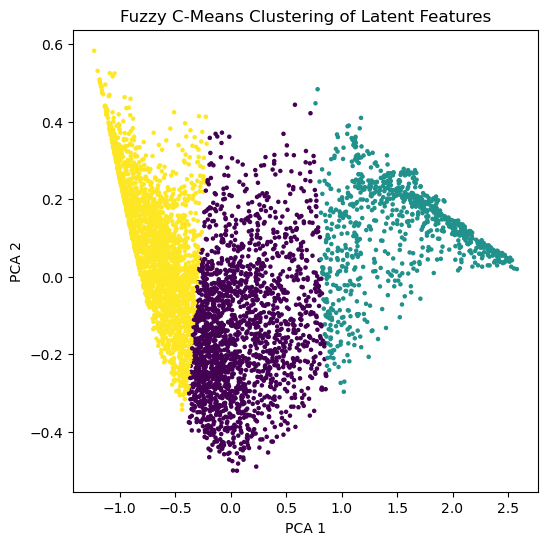

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X2 = pca.fit_transform(X.T)

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=labels, cmap='viridis', s=5)

plt.title("Fuzzy C-Means Clustering of Latent Features")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [8]:
import numpy as np
import glob
from collections import defaultdict

latent_files = glob.glob("D:/LatentFeatures/*_train/*.npy")

cluster_species = defaultdict(lambda: {"canola":0,"soybean":0,"waterhemp":0})

for i,f in enumerate(latent_files):

    if "canola" in f:
        plant = "canola"
    elif "soybean" in f:
        plant = "soybean"
    elif "waterhemp" in f:
        plant = "waterhemp"

    cluster = labels[i]

    cluster_species[cluster][plant] += 1


for c in cluster_species:
    print("Cluster",c,":",cluster_species[c])

Cluster 2 : {'canola': 643, 'soybean': 1060, 'waterhemp': 545}
Cluster 0 : {'canola': 749, 'soybean': 435, 'waterhemp': 736}
Cluster 1 : {'canola': 304, 'soybean': 59, 'waterhemp': 511}


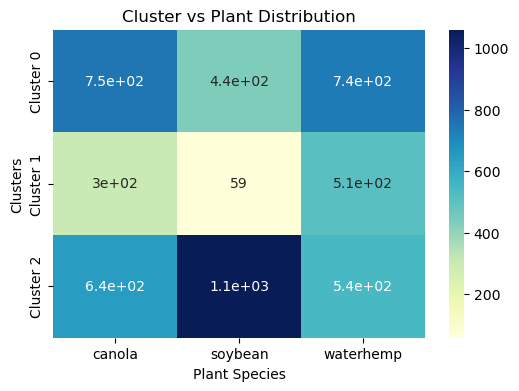

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "canola": [749, 304, 643],
    "soybean": [435, 59, 1060],
    "waterhemp": [736, 511, 545]
}

df = pd.DataFrame(data, index=["Cluster 0", "Cluster 1", "Cluster 2"])

plt.figure(figsize=(6,4))

sns.heatmap(df, annot=True, cmap="YlGnBu")

plt.title("Cluster vs Plant Distribution")
plt.xlabel("Plant Species")
plt.ylabel("Clusters")

plt.show()

In [6]:
import numpy as np
import glob
from collections import defaultdict

latent_files = glob.glob("D:/LatentFeatures/*_train/*.npy")

cluster_files = defaultdict(list)

for i, f in enumerate(latent_files):
    cluster_files[labels[i]].append(f)

for c in cluster_files:
    print(f"Cluster {c}: {len(cluster_files[c])} files")

Cluster 2: 2248 files
Cluster 0: 1920 files
Cluster 1: 874 files


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

def show_cluster_samples(cluster_id, n=6):

    files = cluster_files[cluster_id][:n]

    plt.figure(figsize=(12,4))

    for i,f in enumerate(files):

        # build correct patch path
        patch_file = f.replace("D:/LatentFeatures","E:/project/WeedCube_Patches/train")
        patch_file = patch_file.replace("canola_train","canola")
        patch_file = patch_file.replace("soybean_train","soybean")
        patch_file = patch_file.replace("waterhemp_train","waterhemp")
        patch_file = patch_file.replace("_latent.npy",".npy")

        patch = np.load(patch_file)

        # visualize one spectral band
        img = patch[:,:,50]

        plt.subplot(1,n,i+1)
        plt.imshow(img, cmap="viridis")
        plt.axis("off")

    plt.suptitle(f"Cluster {cluster_id} samples")
    plt.show()

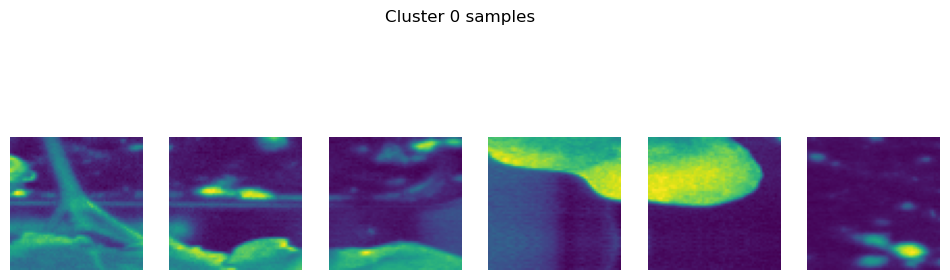

In [12]:
show_cluster_samples(0)

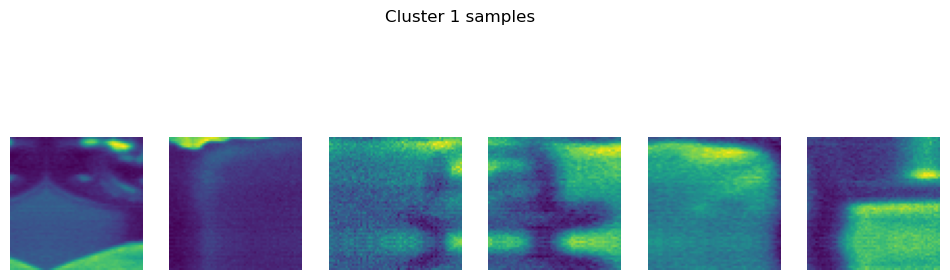

In [13]:
show_cluster_samples(1)

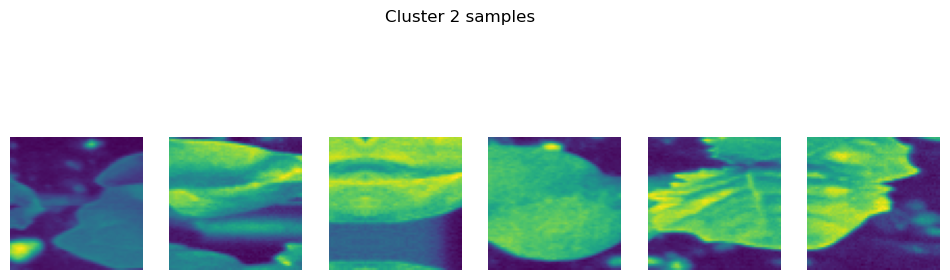

In [14]:
show_cluster_samples(2)

In [15]:
import numpy as np

for c in cluster_files:

    samples = cluster_files[c][:10]

    plants = []

    for f in samples:

        if "canola" in f:
            plants.append("canola")

        elif "soybean" in f:
            plants.append("soybean")

        elif "waterhemp" in f:
            plants.append("waterhemp")

    print("Cluster", c, "sample plants:", plants)

Cluster 2 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']
Cluster 0 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']
Cluster 1 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']


In [16]:
import os

for c in cluster_files:

    samples = cluster_files[c][:10]

    plants = []

    for f in samples:

        filename = os.path.basename(f)

        plant = filename.split("_")[0]

        plants.append(plant)

    print("Cluster", c, "sample plants:", plants)

Cluster 2 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']
Cluster 0 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']
Cluster 1 sample plants: ['canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola', 'canola']


Cluster 2 sample plants: ['soybean', 'canola', 'soybean', 'soybean', 'soybean', 'soybean', 'soybean', 'soybean', 'waterhemp', 'waterhemp']
Cluster 0 sample plants: ['soybean', 'waterhemp', 'canola', 'waterhemp', 'canola', 'soybean', 'soybean', 'soybean', 'canola', 'soybean']
Cluster 1 sample plants: ['waterhemp', 'waterhemp', 'waterhemp', 'canola', 'waterhemp', 'waterhemp', 'waterhemp', 'canola', 'waterhemp', 'waterhemp']


In [6]:
device = torch.device("cpu")

model = HyperspectralAutoencoder().to(device)

model.load_state_dict(
    torch.load("D:/Models/autoencoder_waterhemp.pth")
)

model.eval()

print("Model loaded successfully")

Model loaded successfully
